In [2]:
import ast, re, html, unicodedata
import pandas as pd
from nltk.corpus import stopwords
import numpy as np

#encode
def parse_sentiment(val):
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if s in ('1', '-1', '0'):
        return int(s)
    try:
        d = ast.literal_eval(s)
        basic = (d.get('sentiment') or {}).get('basic') if isinstance(d, dict) else None
        if basic == 'Bullish':  return  1
        if basic == 'Bearish':  return -1
    except Exception:
        pass
    return 0

#Text cleaner
_EMOJI_RE = re.compile(r'[\U0001F300-\U0001F6FF\U0001F900-\U0001F9FF\U0001F1E0-\U0001F1FF]+')

def clean_text(text):
    if pd.isna(text):
        return ''
    s = unicodedata.normalize('NFKC', str(text))
    s = html.unescape(s).lower()
    s = re.sub(r'https?://\S+|www\.\S+', '', s)
    s = re.sub(r'<[^>]+>', '', s)
    s = re.sub(r'@\w+', '', s)
    s = re.sub(r'#\w+', '', s)
    s = _EMOJI_RE.sub('', s)
    return re.sub(r'\s+', ' ', s).strip()

#Stop words
stop_words = set(stopwords.words('english')) | {'stock', 'price', 'market', 'will', 'would', 'could', 'said', 'say'}

def remove_stopwords(text):
    return ' '.join(w for w in str(text).split() if w not in stop_words)

def combine_datasets(d1, name):
    if name == 'amzn':
        return d1
    d2 = pd.read_csv(f"../phase 5/generated_bearish_{name}.csv")
    return pd.concat([d1, d2], ignore_index=True)

def balanced_sample(df, name):
    """Optimized class balancing."""
    idx_1 = df['entities'] == 1
    idx_neg1 = df['entities'] == -1
    idx_0 = df['entities'] == 0

    if name == 'tsla':
        n_neg1 = idx_neg1.sum()
        idx_1_keep = df[idx_1].sample(n=n_neg1, random_state=42).index if idx_1.sum() > n_neg1 else df[idx_1].index
        max_0 = n_neg1 + len(idx_1_keep)
        idx_0_keep = df[idx_0].sample(n=max_0, random_state=42).index if idx_0.sum() > max_0 else df[idx_0].index
        idx_keep = np.concatenate([df[idx_neg1].index, idx_1_keep, idx_0_keep])
    else:
        n_1 = idx_1.sum()
        n_neg1 = idx_neg1.sum()
        idx_neg1_keep = df[idx_neg1].sample(n=n_1, random_state=42).index if n_1 < n_neg1 and n_1 > 0 else df[idx_neg1].index
        idx_keep = np.concatenate([idx_neg1_keep, df[idx_1].index, df[idx_0].index])

    return df.loc[idx_keep].reset_index(drop=True)

#pipeline
stocks = ['amzn', 'aapl', 'fb', 'tsla', 'nvda']
for name in stocks:
    print(f"Processing {name}...")
    df = pd.read_csv(f"{name}_combined.csv")
    df['body'] = df['body'].astype(str)

    before = len(df)
    df = combine_datasets(df, name)

    # 1. Clean entities
    df['entities'] = df['entities'].apply(parse_sentiment).astype(int)

    # 1b. Balance classes
    df = balanced_sample(df, name)

    # 2. Clean text and remove stop words (overwrite body_clean)
    df['body_clean'] = df['body'].apply(clean_text).apply(remove_stopwords)

    # 3. Drop duplicates (keep first occurrence of each unique cleaned post)
    df = df.drop_duplicates(subset=['body_clean'], keep='first')
    
    after = len(df)

    # Ensure dtypes before saving
    df['entities'] = df['entities'].astype(int)
    df['body'] = df['body'].astype(str)

    df.to_csv(f"../pre-processing/{name}_final.csv", index=False)
    print(f"  {before:>10,} rows → {after:>10,} rows  (removed {before - after:,})  saved to {name}_final.csv")

print("\nDone.")

Processing amzn...


C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\1937138699.py:73: DtypeWarning: Columns (1,7,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


entities
 0    268728
 1    173561
-1    163883
Name: count, dtype: int64
[-1  1  0]
     679,409 rows →    606,172 rows  (removed 73,237)  saved to amzn_final.csv
Processing aapl...


C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\1937138699.py:73: DtypeWarning: Columns (7,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


entities
 0    407703
 1    311220
-1    300255
Name: count, dtype: int64
[-1  1  0]
     914,962 rows →  1,019,178 rows  (removed -104,216)  saved to aapl_final.csv
Processing fb...


...

entities
 0    172039
 1    104551
-1    102265
Name: count, dtype: int64
[-1  1  0]
     359,908 rows →    378,855 rows  (removed -18,947)  saved to fb_final.csv
Processing tsla...


C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\1937138699.py:73: DtypeWarning: Columns (13,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


entities
 0    851139
 1    487047
-1    485585
Name: count, dtype: int64
[-1  1  0]
   2,204,889 rows →  1,823,771 rows  (removed 381,118)  saved to tsla_final.csv
Processing nvda...


C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\1937138699.py:73: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


entities
 0    302226
 1    173908
-1    169027
Name: count, dtype: int64
[-1  1  0]
     584,181 rows →    645,161 rows  (removed -60,980)  saved to nvda_final.csv

Done.


C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\45662276.py:10: DtypeWarning: Columns (1,7,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"../pre-processing/{name}_final.csv")
C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\45662276.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"../pre-processing/{name}_final.csv")
C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\45662276.py:10: DtypeWarning: Columns (1,7,8,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"../pre-processing/{name}_final.csv")
C:\Users\jzweb\AppData\Local\Temp\ipykernel_34660\45662276.py:10: DtypeWarning: Columns (1,7,9,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"../pre-processing/{name}_final.csv")
C:\Users\jzweb\AppData\Local\Temp\ipykernel_

BULLISH / BEARISH COUNT PER STOCK
      Bullish  Bearish  Neutral    Total  Bullish %  Bearish %  Neutral %
amzn   173561   163883   268728   606172      28.63      27.04      44.33
fb     104551   102265   172039   378855      27.60      26.99      45.41
aapl   311220   300255   407703  1019178      30.54      29.46      40.00
tsla   487047   485585   851139  1823771      26.71      26.63      46.67
nvda   173908   169027   302226   645161      26.96      26.20      46.85


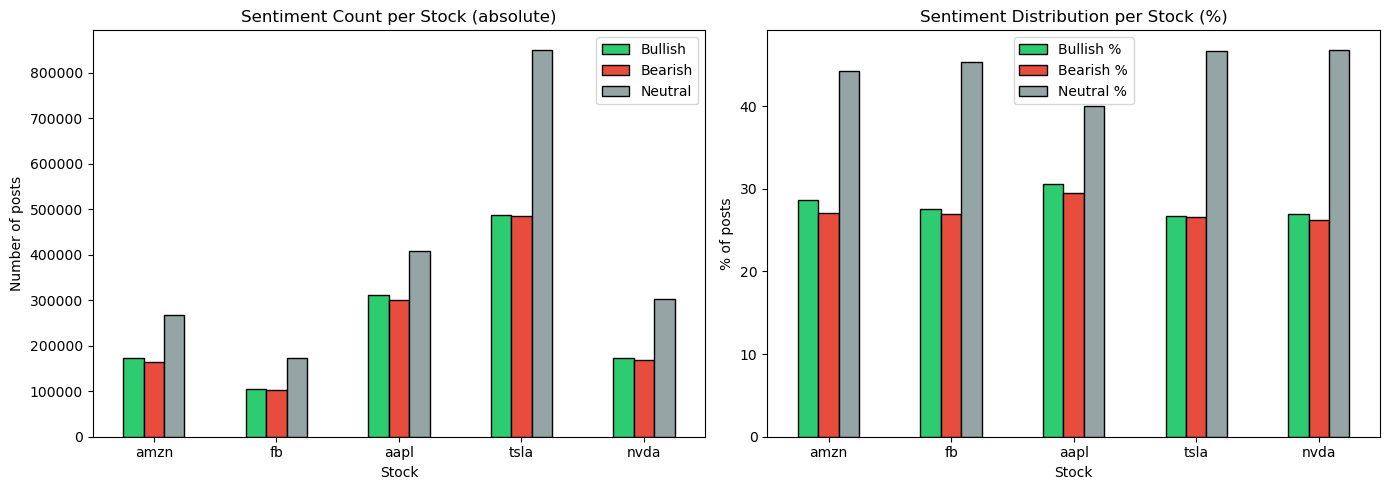

In [5]:
# Bullish / Bearish count per stock
import pandas as pd
import matplotlib.pyplot as plt

sentiment_summary = {}
stocks = ["amzn", "fb", "aapl", "tsla", "nvda"]

for name in stocks:
    try:
        df = pd.read_csv(f"../pre-processing/{name}_final.csv")
    except Exception as e:
        print(f"Could not read {name}_final.csv: {e}")
        continue
    # Ensure correct dtypes
    if 'entities' in df.columns:
        df['entities'] = pd.to_numeric(df['entities'], errors='coerce').astype('Int64')
    counts = df['entities'].value_counts().sort_index()
    sentiment_summary[name] = {
        'Bullish':  int(counts[counts.index == 1].sum()),
        'Bearish':  int(counts[counts.index == -1].sum()),
        'Neutral':  int(counts[counts.index == 0].sum()),
        'Total':    int(len(df)),
    }

summary_df = pd.DataFrame(sentiment_summary).T
if not summary_df.empty and all(col in summary_df.columns for col in ['Bullish', 'Bearish', 'Neutral', 'Total']):
    summary_df['Bullish %'] = (summary_df['Bullish'] / summary_df['Total'] * 100).round(2)
    summary_df['Bearish %'] = (summary_df['Bearish'] / summary_df['Total'] * 100).round(2)
    summary_df['Neutral %'] = (summary_df['Neutral'] / summary_df['Total'] * 100).round(2)

    print("=" * 65)
    print("BULLISH / BEARISH COUNT PER STOCK")
    print("=" * 65)
    print(summary_df[['Bullish', 'Bearish', 'Neutral', 'Total',
                       'Bullish %', 'Bearish %', 'Neutral %']].to_string())

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Absolute counts
    summary_df[['Bullish', 'Bearish', 'Neutral']].plot(
        kind='bar', ax=axes[0],
        color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='black'
    )
    axes[0].set_title('Sentiment Count per Stock (absolute)')
    axes[0].set_xlabel('Stock')
    axes[0].set_ylabel('Number of posts')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend()

    # Percentage
    summary_df[['Bullish %', 'Bearish %', 'Neutral %']].plot(
        kind='bar', ax=axes[1],
        color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='black'
    )
    axes[1].set_title('Sentiment Distribution per Stock (%)')
    axes[1].set_xlabel('Stock')
    axes[1].set_ylabel('% of posts')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No data available for summary.')